In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pl
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
import pandas as pd
from scipy.stats import linregress
from datasets import load_dataset

/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
output_dir = '/home/aditya/hack_model/snli_(0.01, 0.44, 0.55)'

In [ ]:
## my input features
alignment_matrix = np.load(f"{output_dir}/alignment_matrix_M.npy")

In [ ]:
with open(f'{output_dir}/accuracy_arr.pkl','rb') as f:
    accuracy_arr = pl.load(f)

In [ ]:
with open(f'{output_dir}/dataset_info.json') as f:
    dataset_info =json.load(f)

In [ ]:
labels = dataset_info['dataset']

In [ ]:
# We want the experiments with the class pair where everythign else sums up to a constant number and remins constant. 

In [ ]:
def plot_alignment_vs_proportion_focused(experiments, interpolation, class_pair, class_names, tolerance=0.01):
    """
    Plot how mean alignment scores change as we vary proportions between two classes.
    Focus on experiments where other classes are held at 0.3.
    
    Args:
        experiments: list of experiment dicts
        class_pair: tuple of two class indices to focus on
        class_names: Optional list of class names
        tolerance: tolerance for considering proportions as "fixed at 0.3" (default 0.01)
    """
    class_a, class_b = class_pair
    
    print(f"\n{'='*80}")
    print(f"Analyzing class pair: {class_names[class_a]} (Class {class_a}) vs {class_names[class_b]} (Class {class_b})")
    print(f"{'='*80}")
    
    # Find experiments where the OTHER two classes are both fixed at 0.3
    grouped_experiments = []
    
        # Get the other two class indices (not class_a or class_b)
    other_indices = [i for i in range(len(class_names)) if i not in (class_a, class_b)]
    
    for exp in experiments:
        props = exp['proportions']
        if len(props) < len(class_names):
            continue
        
        # Check if BOTH other classes are approximately 0.3
        other_props = [props[i] for i in other_indices]
        
        consistent = True
        for prop in other_props:
            if(prop!=0.3):
                consistent = False
        
        if(not consistent):
            continue
       
        grouped_experiments.append(exp)
    
    print(f"\nFound {len(grouped_experiments)} experiments where other classes are fixed at 0.3:")
    for exp in grouped_experiments:
        print(f"  {exp['proportions']}")
    
    if len(grouped_experiments) < 2:
        print(f"\nNot enough experiments (need at least 2, found {len(grouped_experiments)})")
        return
    
    # Get the two class indices that are fixed
    other_indices = [i for i in range(len(class_names)) if i not in (class_a, class_b)]
    other_class_names = [class_names[idx] for idx in other_indices]
    
    # Compute mean alignment for each experiment
    data = []
    for exp in grouped_experiments:
        props = exp['proportions']
        alignment_matrix = exp['alignment_matrix']
        labels = exp['labels']
        
        mean_per_class = compute_mean_alignment_per_expert_per_class(
            alignment_matrix, labels
        )
        
        n_experts = alignment_matrix.shape[1]
        
        for expert_idx in range(n_experts):
            for cls in [class_a, class_b]:
                if cls in mean_per_class:
                    data.append({
                        'proportion': props[cls],
                        'class': cls,
                        'expert': expert_idx,
                        'mean_alignment': mean_per_class[cls][expert_idx],
                        'class_a_prop': props[class_a],
                        'class_b_prop': props[class_b],
                        'config_name': f"[{','.join([f'{p:.2f}' for p in props])}]"
                    })
    
    if not data:
        print(f"  No data extracted")
        return
    
    df = pd.DataFrame(data)
    
    # Plot for each expert
    n_experts = df['expert'].nunique()
    n_cols = min(3, n_experts)
    n_rows = (n_experts + n_cols - 1) // n_cols
    
    # Adjust figure size to accommodate title
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows + 1), squeeze=False)
    
    # Build title
    title_text = (f'Mean Alignment vs Class Proportion\n'
                 f'Variable: {class_names[class_a]} & {class_names[class_b]} (sum=0.7) | '
                 f'Fixed: {other_class_names[0]}=0.30'
                 f'Interpolation: {interpolation}')
    
    fig.suptitle(title_text, fontsize=14, fontweight='bold', y=0.98)
    
    for expert_idx in range(n_experts):
        r = expert_idx // n_cols
        c = expert_idx % n_cols
        ax = axes[r, c]
        
        df_expert = df[df['expert'] == expert_idx]
        
        # Get all unique proportions for both classes
        all_props_a = df_expert[df_expert['class'] == class_a]['proportion'].unique()
        all_props_b = df_expert[df_expert['class'] == class_b]['proportion'].unique()
        all_props = np.unique(np.concatenate([all_props_a, all_props_b]))
        
        if len(all_props) > 0:
            min_prop = all_props.min()
            max_prop = all_props.max()
        else:
            min_prop, max_prop = 0, 1
        
        colors = ['#1f77b4', '#ff7f0e']  # Blue and orange
                        
                
        df_cls = df_expert[df_expert['class'] == class_a].sort_values('proportion')
        if len(df_cls) > 0:
            ax.plot(df_cls['proportion'], df_cls['mean_alignment'], 
                    marker='o', label=f'{class_names[class_a]}', linewidth=2.5, 
                    markersize=8, color=colors[0], alpha=0.8)
            
            # Add data point labels
            for _, row in df_cls.iterrows():
                ax.annotate(f'{row["mean_alignment"]:.4f}', 
                            (row['proportion'], row['mean_alignment']),
                            textcoords="offset points", xytext=(0, 10), 
                            ha='center', fontsize=7, alpha=0.7,
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[0], alpha=0.2))


        df_cls = df_expert[df_expert['class'] == class_b].sort_values('proportion')
        df_cls['mean_alignment'] = df_cls['mean_alignment'].to_numpy()[::-1]
        if len(df_cls) > 0:
            ax.plot(df_cls['proportion'], df_cls['mean_alignment'], 
                    marker='o', label=f'{class_names[class_b]}', linewidth=2.5, 
                    markersize=8, color=colors[1], alpha=0.8)
            
            # Add data point labels
            for _, row in df_cls.iterrows():
                ax.annotate(f'{row["mean_alignment"]:.4f}', 
                            (row['proportion'], row['mean_alignment']),
                            textcoords="offset points", xytext=(0, 10), 
                            ha='center', fontsize=7, alpha=0.7,
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[1], alpha=0.2))  
                 
        ax.set_yscale('log')        
        
        # Set x-axis limits with padding
        if max_prop > min_prop:
            padding = (max_prop - min_prop) * 0.15
            ax.set_xlim(min_prop - padding, max_prop + padding)
        
        # Format x-axis to show actual proportion values
        ax.set_xticks(sorted(all_props))
        ax.set_xticklabels([f'{p:.2f}' for p in sorted(all_props)], rotation=0)
        
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
        ax.set_xlabel(f'Class Proportion (wrt {class_names[class_a]})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Mean Alignment Score', fontsize=11, fontweight='bold')
        ax.set_title(f'Pseudo-Expert {expert_idx + 1}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_experts, n_rows * n_cols):
        r = idx // n_cols
        c = idx % n_cols
        fig.delaxes(axes[r, c])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print(f"SUMMARY: Variable Classes: {class_names[class_a]} & {class_names[class_b]}")
    print(f"Fixed: {other_class_names[0]}=0.30")
    print(f"Variable classes share: 0.70 of total proportion")
    print("="*80)
    
    # Group by configuration and print stats
    for config_name in sorted(df['config_name'].unique()):
        df_config = df[df['config_name'] == config_name]
        print(f"\nConfiguration: {config_name}")
        
        for expert_idx in range(n_experts):
            df_expert = df_config[df_config['expert'] == expert_idx]
            if len(df_expert) == 0:
                continue
                
            print(f"  Expert {expert_idx + 1}:")
            
            for cls in [class_a, class_b]:
                df_cls = df_expert[df_expert['class'] == cls]
                if len(df_cls) > 0:
                    prop = df_cls['proportion'].values[0]
                    align = df_cls['mean_alignment'].values[0]
                    print(f"    {class_names[cls]:>15} (prop={prop:.2f}): alignment = {align:9.6f}")
    return data

In [ ]:
def load_experiment_data(dataset_name,interpolation_name,base_dir):
    """
    Load all experiment results with their proportions.
    
    Args:
        base_dir: Path to directory containing experiment folders
        
    Returns:
        list: List of dicts with keys 'proportions', 'alignment_matrix', 'labels', 'output_dir'
    """
    base_path = Path(base_dir)
    
    experiments = []
    
    # Find all directories that match the pattern
    all_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith(dataset_name) and interpolation_name in d.name]
    
    print(f"Scanning {len(all_dirs)} directories...")
    
    for output_dir in all_dirs:
        # Try to parse proportions from directory name
        proportions = parse_proportion_from_filename(output_dir.name)
        
        if proportions is None:
            continue
        
        # Check if alignment matrix exists
        alignment_file = f'{output_dir} / alignment_matrix_{interpolation_name}.npy'
        dataset_info_file = output_dir / 'dataset_info.json'
        
        if alignment_file.exists() and dataset_info_file.exists():
            try:
                alignment_matrix = np.load(alignment_file)
                
                with open(dataset_info_file) as f:
                    dataset_info = json.load(f)
                
                experiments.append({
                    'proportions': proportions,
                    'alignment_matrix': alignment_matrix,
                    'labels': dataset_info['dataset'],
                    'output_dir': str(output_dir),
                    'config_name': output_dir.name
                })
                
                # print(f"  ✓ Loaded: {output_dir.name} - shape: {alignment_matrix.shape}, props: {proportions}")
                
            except Exception as e:
                print(f"  ✗ Error loading {output_dir.name}: {e}")
        else:
            missing = []
            if not alignment_file.exists():
                missing.append('alignment_matrix_M.npy')
            if not dataset_info_file.exists():
                missing.append('dataset_info.json')
            print(f"  ⚠ Skipping {output_dir.name}: missing {', '.join(missing)}")
    
    print(f"\n✓ Successfully loaded {len(experiments)} experiments")
    
    # Sort by proportions for easier viewing
    experiments.sort(key=lambda x: tuple(x['proportions']))
    
    return experiments


In [ ]:
import json
import numpy as np
from pathlib import Path
import re

def parse_proportion_from_filename(filename):
    """Extract proportion array from filename like 'ag_news_6e-06_[0.1, 0.3, 0.3, 0.3].json'"""
    match = re.search(r'[\[\(]\s*([0-9eE+\-.,\s]+)\s*[\]\)]', filename)
    if match:
        arr = [float(x) for x in match.group(1).split(",") if x.strip()]
        return arr
    return None

def load_experiment_data(dataset_name, interpolation_name, base_dir):
    """
    Load experiment results with their proportions.
    
    Args:
        dataset_name: Dataset identifier ('snli' or 'ag_news')
        interpolation_name: Method name ('linear', 'slerp', 'ties', 'model_baseline')
        base_dir: Path to results directory
        
    Returns:
        list: Experiment dicts with keys:
              'proportions', 'alignment_matrix', 'labels', 
              'output_dir', 'config_name', 'interpolation'
    """
    base_path = Path(base_dir)
    experiments = []
    
    # Load HuggingFace dataset
    print(f"Loading {dataset_name} dataset from HuggingFace...")
    if dataset_name == 'snli':
        hf_dataset = load_dataset('snli')['train']
    elif dataset_name == 'ag_news':
        hf_dataset = load_dataset('ag_news')['train']
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")
    
    print(f"Dataset loaded: {len(hf_dataset)} samples")
    
    # Find matching directories
    all_dirs = [d for d in base_path.iterdir() 
                if d.is_dir() and d.name.startswith(dataset_name)]
    
    print(f"Scanning {len(all_dirs)} directories...")
    
    for parent_dir in all_dirs:
        proportions = parse_proportion_from_filename(parent_dir.name)
        
        if proportions is None:
            print(f"  ⚠ Could not parse proportions: {parent_dir.name}")
            continue
        
        # File paths
        dataset_info_file = parent_dir / 'dataset_info.json'
        alignment_subdir = parent_dir / interpolation_name
        alignment_file = alignment_subdir / f'alignment_matrix_{interpolation_name}.npy'
        
        # Check files exist
        if not dataset_info_file.exists():
            print(f"  ⚠ Missing dataset_info.json: {parent_dir.name}")
            continue
        
        if not alignment_file.exists():
            print(f"  ⚠ Missing alignment matrix: {parent_dir.name}/{interpolation_name}")
            continue
        
        # Load data
        with open(dataset_info_file) as f:
            dataset_info = json.load(f)
        
        if 'indices_D' not in dataset_info:
            print(f"  ✗ Missing 'indices_D': {parent_dir.name}")
            continue
        
        indices_D = dataset_info['indices_D']
        labels = [hf_dataset[idx]['label'] for idx in indices_D]
        alignment_matrix = np.load(alignment_file)
        
        # Validate
        if alignment_matrix.shape[0] != len(labels):
            print(f"  ✗ Shape mismatch: {parent_dir.name} "
                  f"({alignment_matrix.shape[0]} vs {len(labels)})")
            continue
        
        experiments.append({
            'proportions': proportions,
            'alignment_matrix': alignment_matrix,
            'labels': labels,
            'output_dir': str(parent_dir),
            'config_name': parent_dir.name,
            'interpolation': interpolation_name
        })
        
        print(f"  ✓ {parent_dir.name}/{interpolation_name} "
              f"({alignment_matrix.shape}, {proportions})")
    
    print(f"\n✓ Loaded {len(experiments)} experiments for {interpolation_name}")
    
    experiments.sort(key=lambda x: tuple(x['proportions']))
    
    return experiments

def compute_mean_alignment_per_expert_per_class(alignment_matrix, class_labels):
    """
    Compute mean alignment score for each pseudo-expert for each class.
    
    Args:
        alignment_matrix: np.ndarray, shape (n_samples, n_pseudo_experts)
        class_labels: 1D array-like of length n_samples with class labels
    
    Returns:
        dict: {class_id: np.array([mean_expert_0, mean_expert_1, ...])}
    """
    class_labels = np.array(class_labels)
    unique_classes = np.unique(class_labels)
    n_pseudo_experts = alignment_matrix.shape[1]
    
    results = {}
    
    for cls in unique_classes:
        cls_mask = (class_labels == cls)
        cls_alignment = alignment_matrix[cls_mask]  # (n_samples_cls, n_experts)
        
        if cls_alignment.shape[0] == 0:
            # No samples for this class
            continue
        
        # Mean across samples for each expert
        mean_per_expert = cls_alignment.mean(axis=0)  # shape (n_experts,)
        results[cls] = mean_per_expert
    
    return results

In [ ]:
def plot_alignment_heatmap_across_proportions(experiments, target_class=0, class_names=None):
    """
    Heatmap showing mean alignment for a target class across all pseudo-experts
    for different proportion configurations.
    
    Args:
        experiments: list of experiment dicts
        target_class: which class to focus on
        class_names: Optional list of class names
    """
    if class_names is None:
        class_names = [f'Class {i}' for i in range(4)]
    
    data = []
    
    for exp in experiments:
        props = exp['proportions']
        alignment_matrix = exp['alignment_matrix']
        labels = exp['labels']
        
        mean_per_class = compute_mean_alignment_per_expert_per_class(
            alignment_matrix, labels
        )
        
        if target_class in mean_per_class:
            # Create readable proportion label
            prop_label = '[' + ', '.join([f'{p:.2f}' for p in props]) + ']'
            
            data.append({
                'proportions': prop_label,
                'target_prop': props[target_class],
                'mean_alignments': mean_per_class[target_class],
                'all_props': props
            })
    
    if len(data) == 0:
        print(f"No data found for class {target_class} ({class_names[target_class]})")
        return
    
    # Sort by target class proportion
    data.sort(key=lambda x: x['target_prop'])
    
    # Create matrix for heatmap
    prop_labels = [d['proportions'] for d in data]
    n_experts = len(data[0]['mean_alignments'])
    
    matrix = np.array([d['mean_alignments'] for d in data])
    
    # Calculate figure height based on number of configurations
    fig_height = max(8, len(data) * 0.5)
    
    fig = plt.figure(figsize=(14, fig_height))
    
    sns.heatmap(matrix, 
                xticklabels=[f'Expert {i+1}' for i in range(n_experts)],
                yticklabels=prop_labels,
                cmap='RdBu_r',
                center=0,
                annot=True,
                fmt='.4f',
                cbar_kws={'label': 'Mean Alignment Score'},
                linewidths=0.5,
                linecolor='gray')
    
    plt.title(f'Mean Alignment Score for {class_names[target_class]} (Class {target_class})\n'
              f'Across Proportion Configurations (Sorted by {class_names[target_class]} proportion)', 
              fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Pseudo-Expert', fontsize=12, fontweight='bold')
    plt.ylabel('Class Proportions [Class0, Class1, Class2, Class3]', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*80)
    print(f"HEATMAP SUMMARY FOR {class_names[target_class]} (Class {target_class})")
    print("="*80)
    print(f"\nConfigurations sorted by {class_names[target_class]} proportion:")
    for d in data:
        print(f"\n  {d['proportions']}")
        print(f"    {class_names[target_class]} proportion: {d['target_prop']:.2f}")
        print(f"    Mean alignment per expert:")
        for i, val in enumerate(d['mean_alignments']):
            print(f"      Expert {i+1}: {val:.6f}")
        print(f"    Overall mean: {np.mean(d['mean_alignments']):9.6f}")
        print(f"    Overall std:  {np.std(d['mean_alignments']):9.6f}")

In [ ]:
# you wan teh twonpints about the same exac tthing 
# want it to be specific to the prorotion of one class 

In [ ]:
def run_experiments(class_names,class_pairs,dataset,interpolation,directory_name):
    
    # Load all experiments
    print("Loading experiments...")
    experiments = load_experiment_data(dataset,interpolation,directory_name)
    print(f"Loaded {len(experiments)} experiments")

    # Show available proportion configurations
    print("\nAvailable proportion configurations:")
    for i, exp in enumerate(experiments):
        print(f"  {i+1}. {exp['proportions']}")

    # Plot alignment vs proportion for all class pairs where other 2 are fixed at 0.3
    print("\n" + "="*80)
    print("PLOTTING ALIGNMENT VS PROPORTION FOR CLASS PAIRS")
    print("="*80)

    for pair in class_pairs:
        print(len(experiments))
        data = plot_alignment_vs_proportion_focused(experiments, interpolation, class_pair=pair, class_names=class_names)
        print(data)

    # Heatmap for each class
    print("\n" + "="*80)
    print("PLOTTING HEATMAPS FOR EACH CLASS")
    print("="*80)

    # for target_class in range(len(class_names)):
    #     plot_alignment_heatmap_across_proportions(experiments, target_class=target_class, class_names=class_names)

In [ ]:
# Define class names for AG News
class_names = ['entailement','neutral','contradiction']

# Plot for class pairs (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
class_pairs = [(0, 1), (0, 2), (1, 2)]

dataset = 'snli'

interpolations = ['model_baseline','slerp','ties','linear']

directory_name = '/home/aditya/hack_model/results1'

for interpolation in interpolations: 
    run_experiments(class_names,class_pairs,dataset,interpolation,directory_name)

In [ ]:
def generate_data_for_linear_plots(dataset,interpolation,directory_name,classa,classb):
    
        # Load all experiments
    print("Loading experiments...")
    experiments = load_experiment_data(dataset,interpolation,directory_name)
    print(f"Loaded {len(experiments)} experiments")
    
    
    # Compute mean alignment for each experiment
    data_a = []
    data_b = []
    for exp in experiments:
        props = exp['proportions']
        alignment_matrix = exp['alignment_matrix']
        labels = exp['labels']
        
        mean_per_class = compute_mean_alignment_per_expert_per_class(alignment_matrix, labels)
        
        data_a.append({
            'class_a_proportion': [props[classa]]*15,
            'class_a_alignscores': mean_per_class[classa],
        })
        
        data_b.append({
            'class_b_proportion': [props[classb]]*15,
            'class_b_alignscores': mean_per_class[classb]
        })
    
    return data_a,data_b

In [ ]:
def generate_linear_plots(dataset,interpolation,directory_name,classa,classb):
    
    data_a,data_b = generate_data_for_linear_plots(dataset,interpolation,directory_name,classa,classb)
    
    class_a_prop = np.empty(0)
    class_a_alignscores = np.empty(0)
    for dic in data_a:  
        class_a_prop = np.append(class_a_prop,dic['class_a_proportion'])
        class_a_alignscores = np.append(class_a_alignscores,dic['class_a_alignscores'])
        
    class_b_prop = np.empty(0)
    class_b_alignscores = np.empty(0)
    for dic in data_b:   
        class_b_prop = np.append(class_b_prop,dic['class_b_proportion'])
        class_b_alignscores = np.append(class_b_alignscores,dic['class_b_alignscores'])
        
    plt.scatter(class_a_prop,class_a_alignscores, color='blue', label='Dataset A', marker='o')
    plt.scatter(class_b_prop,class_b_alignscores, color='orange', label='Dataset B', marker='s')
    
    m1, c1, r_value1, p_value1, std_err1 = linregress(class_a_prop,class_a_alignscores)
    plt.plot(class_a_prop, m1*class_a_alignscores + c1, color='blue', linestyle='--', label='Trend A')

    # Trend line for Dataset B
    m2, c2, r_value2, p_value2, std_err2 = linregress(class_b_prop,class_b_alignscores)
    plt.plot(class_b_prop, m2*class_b_alignscores + c2, color='orange', linestyle='-', label='Trend B')

    # 4. Add labels, a legend, and display the plot
    plt.title(f"{interpolation}, (A: {class_names[classa]},B: {class_names[classb]})")
    plt.xlabel("X values")
    plt.ylabel("Y values")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def generate_box_plots(dataset,interpolation,directory_name,classa,classb):
    data_a,data_b = generate_data_for_linear_plots(dataset,interpolation,directory_name,classa,classb)
    
    # class_a_prop = np.empty(0)
    # class_a_alignscores = np.empty(0)
    # for dic in data_a:  
    #     class_a_prop = np.append(class_a_prop,[dic['class_a_proportion'][0]],axis=0)
    #     class_a_alignscores = np.append(class_a_alignscores,dic['class_a_alignscores'],axis=0)

    # class_b_prop = np.empty(0)
    # class_b_alignscores = np.empty(0)
    # for dic in data_b:   
    #     class_b_prop = np.append(class_b_prop,[dic['class_b_proportion'][0]],axis=0)
    #     class_b_alignscores = np.append(class_b_alignscores,dic['class_b_alignscores'],axis=0)
    
   
    # Prepare data for box plots
    box_data_a = []  # List of arrays, one per unique proportion
    box_data_b = []
    unique_props_a = []
    unique_props_b = []
    
    # Group alignment scores by proportion for class A
    prop_dict_a = {}
    for dic in data_a:
        prop = dic['class_a_proportion'][0]
        scores = dic['class_a_alignscores']
        
        if prop not in prop_dict_a:
            prop_dict_a[prop] = []
        prop_dict_a[prop].extend(scores)
    
    # Convert to sorted lists
    for prop in sorted(prop_dict_a.keys()):
        unique_props_a.append(prop)
        box_data_a.append(prop_dict_a[prop])
    
    # Group alignment scores by proportion for class B
    prop_dict_b = {}
    for dic in data_b:
        prop = dic['class_b_proportion'][0]
        scores = dic['class_b_alignscores']
        
        if prop not in prop_dict_b:
            prop_dict_b[prop] = []
        prop_dict_b[prop].extend(scores)
    
    # Convert to sorted lists
    for prop in sorted(prop_dict_b.keys()):
        unique_props_b.append(prop)
        box_data_b.append(prop_dict_b[prop])
    
    # Create side-by-side box plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Box plot for Class A
    bp1 = axes[0].boxplot(box_data_a, 
                          labels=[f'{p:.2f}' for p in unique_props_a],
                          patch_artist=True,
                          widths=0.6)
    
    # Color the boxes
    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    
    axes[0].set_xlabel('Class Proportion', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{class_names[classa]} - {interpolation}', 
                      fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Box plot for Class B
    bp2 = axes[1].boxplot(box_data_b,
                          labels=[f'{p:.2f}' for p in unique_props_b],
                          patch_artist=True,
                          widths=0.6)
    
    # Color the boxes
    for patch in bp2['boxes']:
        patch.set_facecolor('#ff7f0e')
        patch.set_alpha(0.7)
    
    axes[1].set_xlabel('Class Proportion', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{class_names[classb]} - {interpolation}', 
                      fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.suptitle(f'Alignment Score Distribution Across Pseudo-Experts\n'
                 f'{interpolation} | Class Pair: {class_names[classa]} vs {class_names[classb]}',
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"Box Plot Summary: {interpolation}")
    print(f"Class A: {class_names[classa]} | Class B: {class_names[classb]}")
    print(f"{'='*80}")
    
    print(f"\n{class_names[classa]} Statistics:")
    for prop, data in zip(unique_props_a, box_data_a):
        print(f"  Proportion {prop:.2f}: "
              f"median={np.median(data):.6f}, "
              f"mean={np.mean(data):.6f}, "
              f"std={np.std(data):.6f}, "
              f"n={len(data)}")
    
    print(f"\n{class_names[classb]} Statistics:")
    for prop, data in zip(unique_props_b, box_data_b):
        print(f"  Proportion {prop:.2f}: "
              f"median={np.median(data):.6f}, "
              f"mean={np.mean(data):.6f}, "
              f"std={np.std(data):.6f}, "
              f"n={len(data)}")
    
    

In [ ]:
for interpolation in interpolations:
    for classa,classb in class_pairs:
        generate_box_plots(dataset,interpolation,directory_name,classa,classb)
        # generate_linear_plots(dataset,interpolation,directory_name,classa,classb)

### generating alignment scores

In [21]:
import numpy as np
from pathlib import Path
import re
from tqdm import tqdm

def normalize_max(matrix):
    """Scale to [0,1] per expert"""
    max_val = matrix.max(axis=0, keepdims=True)
    max_val = np.where(max_val == 0, 1, max_val)  # Avoid division by zero
    return matrix / max_val

def normalize_standard(matrix):
    """Z-score per expert"""
    mean = matrix.mean(axis=0, keepdims=True)
    std = matrix.std(axis=0, keepdims=True, ddof=0)
    return (matrix - mean) / np.where(std == 0, 1, std)

def normalize_all(dataset, interpolation, base_dir, norm_type):
    """Normalize all matrices for dataset/interpolation"""
    
    norm_fn = normalize_max if norm_type == 'max' else normalize_standard
    base_path = Path(base_dir)
    
    # Find all experiment directories
    dirs = [d for d in base_path.iterdir() 
            if d.is_dir() and d.name.startswith(f"{dataset}_{interpolation}_[")]
    
    stats = {'success': 0, 'skipped': 0}
    
    for exp_dir in tqdm(dirs, desc=f"{dataset}/{interpolation}/{norm_type}"):
        input_file = exp_dir / f"alignment_matrix_{interpolation}.npy"
        output_file = exp_dir / f"alignment_matrix_{interpolation}_{norm_type}.npy"
        
        # Load, normalize, save
        matrix = np.load(input_file)
        normalized = norm_fn(matrix)
        np.save(output_file, normalized)
        stats['success'] += 1
    
    print(f"  {dataset}/{interpolation}/{norm_type}: ✓{stats['success']} ⊘{stats['skipped']}")
    return stats

# ============================================
# Run
# ============================================
if __name__ == "__main__":
    
    DATASETS = ['ag_news', 'yelp_review']
    INTERPOLATIONS = ['linear', 'slerp', 'ties', 'model_baseline']
    NORMALIZATIONS = ['max', 'standard']
    
    for dataset in DATASETS:
        base_dir = f'/home/aditya/hack_model/results_align_matrix_{dataset}'
        
        for interp in INTERPOLATIONS:
            for norm in NORMALIZATIONS:
                stats = normalize_all(dataset, interp, base_dir, norm)
                print(stats)
    
    print("\n✅ Done!")

ag_news/linear/max: 100%|██████████| 36/36 [00:00<00:00, 815.05it/s]


  ag_news/linear/max: ✓36 ⊘0
{'success': 36, 'skipped': 0}


ag_news/linear/standard: 100%|██████████| 36/36 [00:00<00:00, 737.68it/s]


  ag_news/linear/standard: ✓36 ⊘0
{'success': 36, 'skipped': 0}


ag_news/slerp/max: 100%|██████████| 36/36 [00:00<00:00, 870.06it/s]


...

  yelp_review/ties/standard: ✓42 ⊘0
{'success': 42, 'skipped': 0}


yelp_review/model_baseline/max: 100%|██████████| 42/42 [00:00<00:00, 963.36it/s]


  yelp_review/model_baseline/max: ✓42 ⊘0
{'success': 42, 'skipped': 0}


yelp_review/model_baseline/standard: 100%|██████████| 42/42 [00:00<00:00, 879.66it/s]

  yelp_review/model_baseline/standard: ✓42 ⊘0
{'success': 42, 'skipped': 0}

✅ Done!


#### Getting training points

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold  # ← Just for splitting indices!
import os
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

In [3]:
import json
import numpy as np
from pathlib import Path
import re

def parse_proportion_from_filename(filename):
    """Extract proportion array from filename like 'ag_news_6e-06_[0.1, 0.3, 0.3, 0.3].json'"""
    match = re.search(r'[\[\(]\s*([0-9eE+\-.,\s]+)\s*[\]\)]', filename)
    if match:
        arr = [float(x) for x in match.group(1).split(",") if x.strip()]
        return arr
    return None

def load_experiment_data(dataset_name, interpolation_name, normalization, base_dir, data_dir):
    """
    Load experiment results with their proportions.

    Args:
        dataset_name: Dataset identifier ('snli' or 'ag_news')
        interpolation_name: Method name ('linear', 'slerp', 'ties', 'model_baseline')
        base_dir: Directory containing alignment result folders
        data_dir: Directory containing dataset folders with dataset_info.json

    Returns:
        list[dict]: Loaded experiment records
    """
    base_path = Path(base_dir)
    data_path = Path(data_dir)

    print(f"Loading {dataset_name} dataset from HuggingFace...")
    
    if(dataset_name!="yelp_review"):
        hf_dataset = _load_hf_train_split(dataset_name)
    else:
        hf_dataset = _load_hf_train_split('yelp/yelp_review_full') 
    print(f"Dataset loaded: {len(hf_dataset)} samples")

    experiment_dirs = sorted(
        d for d in base_path.iterdir()
        if d.is_dir() and d.name.startswith(f'{dataset_name}_{interpolation_name}_[')
    )

    print(f"Scanning {len(experiment_dirs)} directories...")

    experiments = []

    for exp_dir in experiment_dirs:
        proportions = parse_proportion_from_filename(exp_dir.name)
        if proportions is None:
            print(f"  ⚠ Could not parse proportions: {exp_dir.name}")
            continue

        data_config_name = f"{dataset_name}_({', '.join(map(str, proportions))})"
        dataset_info_file = data_path / data_config_name / "dataset_info.json"
        alignment_file = exp_dir / f"alignment_matrix_{interpolation_name}_{normalization}.npy"

        if not dataset_info_file.exists():
            print(f"  ⚠ Missing dataset_info.json: {dataset_info_file}")
            continue

        if not alignment_file.exists():
            print(f"  ⚠ Missing alignment matrix: {alignment_file}")
            continue

        with dataset_info_file.open() as f:
            dataset_info = json.load(f)

        indices_D = dataset_info["indices_D"]
        labels = [hf_dataset[idx]["label"] for idx in indices_D]
        alignment_matrix = np.load(alignment_file)

        experiments.append({
            "proportions": proportions,
            "alignment_matrix": alignment_matrix,
            "labels": labels,
            "output_dir": str(exp_dir),
            "config_name": exp_dir.name,
            "interpolation": interpolation_name,
            "normalization": normalization
        })

    print(f"\n✓ Loaded {len(experiments)} experiments for {interpolation_name}")

    experiments.sort(key=lambda x: tuple(x["proportions"]))
    return experiments


def _load_hf_train_split(dataset_name):
    return load_dataset(dataset_name, split="train")

def compute_mean_alignment_per_expert_per_class(alignment_matrix, class_labels):
    """
    Compute mean alignment score for each pseudo-expert for each class.
    
    Args:
        alignment_matrix: np.ndarray, shape (n_samples, n_pseudo_experts)
        class_labels: 1D array-like of length n_samples with class labels
    
    Returns:
        dict: {class_id: np.array([mean_expert_0, mean_expert_1, ...])}
    """
    class_labels = np.array(class_labels)
    unique_classes = np.unique(class_labels)
    n_pseudo_experts = alignment_matrix.shape[1]
    
    results = {}
    
    for cls in unique_classes:
        cls_mask = (class_labels == cls)
        cls_alignment = alignment_matrix[cls_mask]  # (n_samples_cls, n_experts)
        
        if cls_alignment.shape[0] == 0:
            # No samples for this class
            continue
        
        # Mean across samples for each expert
        mean_per_expert = cls_alignment.mean(axis=0)  # shape (n_experts,)
        results[cls] = mean_per_expert
    return results


def compute_std_dev_alignment_per_expert_per_class(alignment_matrix, class_labels):
    """
    Compute std dev of alignment score for each pseudo-expert for each class.
    
    Args:
        alignment_matrix: np.ndarray, shape (n_samples, n_pseudo_experts)
        class_labels: 1D array-like of length n_samples with class labels
    
    Returns:
        dict: {class_id: np.array([std_expert_0, std_expert_1, ...])}
    """
    class_labels = np.array(class_labels)
    unique_classes = np.unique(class_labels)
    n_pseudo_experts = alignment_matrix.shape[1]
    
    results = {}

    for cls in unique_classes:
        cls_mask = (class_labels == cls)
        cls_alignment = alignment_matrix[cls_mask]  # (n_samples_cls, n_experts)
        
        if cls_alignment.shape[0] == 0:
            # No samples for this class
            continue
        
        # Mean across samples for each expert
        std_per_expert = cls_alignment.std(axis=0, ddof=0)  
        results[cls] = std_per_expert 
    
    return results

In [4]:
def get_all_scores(dataset_name, interpolation_name, normalization, base_dir,data_dir):
        
    # Load all experiments using existing function
    experiments = load_experiment_data(dataset_name, interpolation_name, normalization,  base_dir,data_dir)
    print(f"Loaded {len(experiments)} experiments for {interpolation_name}")
    
    proportions_arr = []
    mean_per_class_arr = []
    std_per_class_arr = []
    
    for exp in experiments:
        
        proportion = exp['proportions']
        alignment_matrix = exp['alignment_matrix']
        labels = exp['labels']
        
        # Use existing function to compute mean per class
        mean_per_class = compute_mean_alignment_per_expert_per_class(
            alignment_matrix, labels
        )
        
        std_per_class = compute_std_dev_alignment_per_expert_per_class(
            alignment_matrix, labels)
        
        proportions_arr.append(proportion)
        mean_per_class_arr.append(mean_per_class)
        std_per_class_arr.append(std_per_class)
        
    return proportions_arr, mean_per_class_arr, std_per_class_arr

In [5]:
def extract_training_data_for_simple(proportions_arr,mean_per_class_arr,std_dev_per_class_arr, n_classes,n_pseudoexperts,stdOrNot):
    """
    Extract training data for FCN using existing functions.
    
    Returns:
        X: np.array of shape (n_experiments, n_features)
           Features = mean alignment scores per class per expert (3 * 15 = 45)
        y: np.array of shape (n_experiments, n_classes)
           Target class proportions
        metadata: list of dicts with experiment info
    """
    
    X_list = []
    y_list = []
    
    for i in range(len(proportions_arr)):
        
        mean_per_class = mean_per_class_arr[i]
        std_dev_per_class = std_dev_per_class_arr[i]
        
        # Build feature vector: concatenate mean alignment for all classes
        feature_vector = []
        for cls in sorted(mean_per_class.keys()):  
            feature_vector.extend(mean_per_class[cls])  # 15 values per class   
            if(stdOrNot):
                feature_vector.extend(std_dev_per_class[cls])  # 15 values per class
            
        X_list.append(feature_vector)
        y_list.append(proportions_arr[i])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    print(f"\n✓ Extracted {len(X)} training samples")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    
    return X, y

In [6]:
from itertools import combinations

def extract_training_data_for_optimizer(proportions_arr, mean_per_class_arr, n_classes=3):
    """
    Extract pairwise training data for optimizer.
    
    Returns:
        X: (n_samples, 30) - features for 2 classes
        y: (n_samples, 2) - proportions for 2 classes
    """
    
    X_list = []
    y_list = []
    metadata_list = []
    
    # All possible pairs: (0,1), (0,2), (1,2) # least class number first 
    class_pairs = list(combinations(range(n_classes), 2))
    
    for proportions, mean_per_class in zip(proportions_arr, mean_per_class_arr):
        
        # For each pair, create one sample
        for class_i, class_j in class_pairs:
            
            if class_i not in mean_per_class or class_j not in mean_per_class:
                continue
            
            # Features: concat alignments from both classes
            features = np.concatenate([
                mean_per_class[class_i],  # 15 values
                mean_per_class[class_j]   # 15 values
            ])  # Total: 30
            
            # Targets: proportions for this pair
            targets = np.array([proportions[class_i], proportions[class_j]])
            
            class_indices = np.array([class_i, class_j])
            X_list.append(features)
            y_list.append(targets)
            metadata_list.append(class_indices)

    
    X = np.array(X_list)
    y = np.array(y_list)
    metadata = np.array(metadata_list)
    
    print(f"✓ Extracted {len(X)} samples")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    
    return X, y, metadata

In [64]:
# Usage
if __name__ == "__main__":
    datasets = ['ag_news','yelp_review']
    interpolations = ['model_baseline', 'slerp', 'ties', 'linear']
    normalizations = ['max','standard']
    n_pseudoexperts = 15
    statistics = ["mean","mean&std"]
    
    
    for statistic in statistics:
        for dataset in datasets:
            for interpolation in interpolations:
                for normalization in normalizations:

                    base_dir = f'/home/aditya/hack_model/results_align_matrix_{dataset}'
                    data_dir = f'/home/aditya/hack_model/results_datainfo_{dataset}'
                
                    proportions_arr, mean_per_class_arr, std_dev_per_class_arr = get_all_scores(dataset, interpolation, normalization, base_dir,data_dir)
                    
                    n_classes = len(proportions_arr[0])        
                    
                    
                    if(statistic=="mean"):
                        X_simple, y_simple = extract_training_data_for_simple(proportions_arr, mean_per_class_arr, std_dev_per_class_arr, n_classes, n_pseudoexperts,False)
                        # X_optimizer, y_optimizer,metadata = extract_training_data_for_optimizer(proportions_arr, mean_per_class_arr)
                    elif (statistic=="mean&std"):
                        X_simple, y_simple = extract_training_data_for_simple(proportions_arr, mean_per_class_arr, std_dev_per_class_arr, n_classes, n_pseudoexperts,True)

                    np.save(f'X_{dataset}_{interpolation}_{normalization}_simple_{statistic}.npy', X_simple)
                    np.save(f'y_{dataset}_{interpolation}_{normalization}_simple_{statistic}.npy', y_simple)
                    
                    # np.save(f'X_{dataset}_{interpolation}_optimizer.npy', X_optimizer)
                    # np.save(f'y_{dataset}_{interpolation}_optimizer.npy', y_optimizer)
                    
                    print(f"✓ Saved {interpolation}\n")

Loading ag_news dataset from HuggingFace...
Dataset loaded: 120000 samples
Scanning 36 directories...

✓ Loaded 36 experiments for model_baseline
Loaded 36 experiments for model_baseline

✓ Extracted 36 training samples
  X shape: (36, 60)
  y shape: (36, 4)
✓ Saved model_baseline

Loading ag_news dataset from HuggingFace...
Dataset loaded: 120000 samples
Scanning 36 directories...

✓ Loaded 36 experiments for model_baseline
Loaded 36 experiments for model_baseline

✓ Extracted 36 training samples
  X shape: (36, 60)
  y shape: (36, 4)
✓ Saved model_baseline

Loading ag_news dataset from HuggingFace...
Dataset loaded: 120000 samples
Scanning 36 directories...

✓ Loaded 36 experiments for slerp
Loaded 36 experiments for slerp

✓ Extracted 36 training samples
  X shape: (36, 60)
  y shape: (36, 4)
✓ Saved slerp

Loading ag_news dataset from HuggingFace...
Dataset loaded: 120000 samples
Scanning 36 directories...

✓ Loaded 36 experiments for slerp
Loaded 36 experiments for slerp

✓ Extrac

#### Building the models

In [3]:
#computing the ratios for all classes is done in 2 inference runs. 
# now the question is do we want to include the all the classes in the minimize equation..
# how do we begin to choose ...cause we have the ratios for all classes 


# for backprop we cant do it specificaly for 2 classes..we have different distiruvtion of training poitns so that 
# it learns to learn the mappign between the relative differenc ein alignmenet score between any two classes and the 
# proportion. 


# (0,1), (0,2)  (1,2)

# we could have any two out of the three, in each case on which proportions of class_ids should 
# be backprop...theres no cocnept of a particualr class_id being a dof, since all three classes will have their pseudoepxerts once 
# in the frward pass and in oen trainign datapoint. 


# also the model is taking in x, we should change x to be an array to have the first element as the 
# alignment scores of 2 classes with all its pseudoexperts concatenated together 

# and the seocnd elemnt to have alignment scores of 2 classes with all its pseudoexperts concatenated together 


# training on DOF 
# training on all class ratios 

# the thing is the no of trainign poitns will icnrease if we do ti on DOF. instead fo three forward passes toc pmpute allr atiosna nd then optimizer, 
# we will have 2 forward passes and three such forward apsses where each class pair will be different. 




# if we chnage the forward equation, the otuptu we get during trainign is the same output we will get during inference. 


# alpha = a/c , beta = b/c , but this could eb anything...it need not be the same class_id position..




#### Kfold script

In [32]:
class ProportionFCN(nn.Module):
    """
    FCN to predict class proportions from alignment metrics.
    
    Input: (batch, 45) - mean alignment scores [class0_e0...class0_e14, class1_e0...class1_e14, class2_e0...class2_e14]
    Output: (batch, 3) - class proportions that sum to 1
    """
    def __init__(self, n_classes, no_of_stats, n_experts, hidden_dim):
        super().__init__()
        
        input_dim = n_classes * n_experts * no_of_stats
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            # nn.Linear(hidden_dim, hidden_dim),
            # nn.ReLU(),
            # nn.Linear(hidden_dim, hidden_dim),
            # nn.ReLU(),
            nn.Linear(hidden_dim, n_classes)
        )
    
    def forward(self, x):
        logits = self.network(x)
        proportions = F.softmax(logits, dim=1)
        return proportions

In [33]:
def train_fcn_with_kfold(X, y, model_class, n_classes, n_stats , n_folds=10, epochs=100, batch_size=8, lr=1e-3, device='cuda'):
    """
    K-Fold CV with PyTorch model - FIXED VERSION
    
    Args:
        X: Input features (numpy array)
        y: Target labels (numpy array)
        model_class: Callable that returns a fresh model instance
        n_folds: Number of folds for cross-validation
        epochs: Number of training epochs per fold
        batch_size: Batch size for training
        lr: Learning rate
        device: Device to train on ('cuda' or 'cpu')
    
    Returns:
        fold_results: List of dicts with metrics for each fold
    """
    
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        print(f"\n{'='*60}")
        print(f"Fold {fold + 1}/{n_folds}")
        print(f"{'='*60}")
        
        # ✅ FIX 1: Create fresh model for each fold
        model = model_class(n_classes,n_stats).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.L1Loss()
        
        X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
        y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
        
        train_dataset = TensorDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        best_val_loss = float('inf')
        best_epoch = 0
        
        for epoch in range(epochs):
            # Training phase
            model.train()
            train_loss = 0.0
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                optimizer.zero_grad()
                pred = model(batch_X)
                loss = criterion(pred, batch_y)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            train_loss /= len(train_loader)
            
            # Validation phase
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val.to(device))
                val_loss = criterion(val_pred, y_val.to(device)).item()
            
            # ✅ FIX 2: Only print at intervals
            if (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1:3d}: Train={train_loss:.6f}, Val={val_loss:.6f}")
        
        # ============================================
        # Evaluate best model on both train and val sets
        # ============================================
        model.eval()
        
        with torch.no_grad():
            # Validation metrics
            val_pred = model(X_val.to(device))
            val_mse = nn.MSELoss()(val_pred, y_val.to(device)).item()
            val_mae = torch.mean(torch.abs(val_pred - y_val.to(device))).item()
            
            # Training metrics (on best model)
            train_pred = model(X_train.to(device))
            train_mse = nn.MSELoss()(train_pred, y_train.to(device)).item()
            train_mae = torch.mean(torch.abs(train_pred - y_train.to(device))).item()
        
        print(f"  Train MSE: {train_mse:.6f} | Train MAE: {train_mae:.6f}")
        print(f"  Val   MSE: {val_mse:.6f} | Val   MAE: {val_mae:.6f}")

        fold_results.append({
            'fold': fold + 1,
            'train_mse': train_mse,
            'train_mae': train_mae,
            'val_mse': val_mse,
            'val_mae': val_mae
        })
        
        # Show sample predictions at the end of fold
        print(f"\nSample Predictions (first 3):")
        for i in range(min(3, len(val_pred))):
            print(f"  Pred: {val_pred[i].cpu().numpy()} | True: {y_val[i].cpu().numpy()}")
    
    # ============================================
    # Aggregate results across all folds
    # ============================================
    print(f"\n{'='*60}")
    print("Overall K-Fold CV Results:")
    print(f"{'='*60}")
    
    # Training metrics
    avg_train_mse = np.mean([r['train_mse'] for r in fold_results])
    std_train_mse = np.std([r['train_mse'] for r in fold_results])
    avg_train_mae = np.mean([r['train_mae'] for r in fold_results])
    std_train_mae = np.std([r['train_mae'] for r in fold_results])
    
    # Validation metrics
    avg_val_mse = np.mean([r['val_mse'] for r in fold_results])
    std_val_mse = np.std([r['val_mse'] for r in fold_results])
    avg_val_mae = np.mean([r['val_mae'] for r in fold_results])
    std_val_mae = np.std([r['val_mae'] for r in fold_results])
    
    print(f"\nTraining Set:")
    print(f"  Average MSE: {avg_train_mse:.6f} ± {std_train_mse:.6f}")
    print(f"  Average MAE: {avg_train_mae:.6f} ± {std_train_mae:.6f}")
    
    print(f"\nValidation Set:")
    print(f"  Average MSE: {avg_val_mse:.6f} ± {std_val_mse:.6f}")
    print(f"  Average MAE: {avg_val_mae:.6f} ± {std_val_mae:.6f}")
    
    fold_results.append({
        'avg_train_mse': avg_train_mse ,
        'std_train_mse': std_train_mse,
        'avg_train_mae': avg_train_mae,
        'std_train_mae': std_train_mae,
        'avg_val_mse' : avg_val_mse,
        'std_val_mse' : std_val_mse,
        'avg_val_mae' : avg_val_mae,
        'std_val_mae' : std_val_mae
    })
    
    return fold_results

In [34]:
no_of_layers = 2

In [35]:
if __name__ == "__main__":
    device = 'cuda'
    
    def create_model(n_classes,no_of_stats):
        return ProportionFCN(n_classes, no_of_stats, n_experts = 15, hidden_dim = 64)
    
    results_simple = {}
    
    datasets = ['ag_news','yelp_review']
    interpolations = ['model_baseline', 'slerp', 'ties', 'linear']
    normalizations = ['max','standard']
    statistics = ['mean','mean&std']
    
    # ['mean','mean&std']
    
    for statistic in statistics:
        if(statistic=="mean"):
            n_stats = 1
        else:
            n_stats = 2
        for normalization in normalizations:
            for dataset in datasets:
                for interpolation in interpolations:
                    print(f"\n{'='*80}")
                    print(f"Training on {interpolation.upper()}")
                    print(f"{'='*80}")
                    
                    X = np.load(f'X_{dataset}_{interpolation}_{normalization}_simple_{statistic}.npy')
                    y = np.load(f'y_{dataset}_{interpolation}_{normalization}_simple_{statistic}.npy')
                    print(f"Data: X={X.shape}, y={y.shape}")
                    
                    n_classes = y.shape[1]
                    
                    # ✅ Pass model factory, not instance
                    result = train_fcn_with_kfold(
                        X, y, 
                        create_model,
                        n_classes,
                        n_stats,
                        n_folds=10, 
                        epochs=50, 
                        batch_size=8, 
                        lr=1e-3, 
                        device=device
                    )
        
                    print("\n✓ Training complete!")

                    with open(f'results_{dataset}_{interpolation}_{normalization}_simple_{no_of_layers}_{statistic}.pkl','wb') as f:
                        pl.dump(result,f)


Training on MODEL_BASELINE
Data: X=(36, 60), y=(36, 4)

Fold 1/10
Epoch  20: Train=0.075768, Val=0.123162
Epoch  40: Train=0.046875, Val=0.081459
  Train MSE: 0.002530 | Train MAE: 0.033377
  Val   MSE: 0.008524 | Val   MAE: 0.068751

Sample Predictions (first 3):
  Pred: [0.18660158 0.06901337 0.33282706 0.41155794] | True: [0.11 0.09 0.37 0.43]
  Pred: [0.23566662 0.3711989  0.3378809  0.05525361] | True: [0.32 0.39 0.24 0.05]
  Pred: [0.34624645 0.4026492  0.10173308 0.14937131] | True: [0.43 0.44 0.01 0.12]

Fold 2/10
Epoch  20: Train=0.080905, Val=0.052764
Epoch  40: Train=0.045415, Val=0.032986
  Train MSE: 0.002451 | Train MAE: 0.032468
  Val   MSE: 0.000708 | Val   MAE: 0.021203

Sample Predictions (first 3):
  Pred: [0.11824186 0.07405456 0.33401042 0.4736932 ] | True: [0.1  0.11 0.34 0.45]
  Pred: [0.16243477 0.3162402  0.24395065 0.27737445] | True: [0.13 0.35 0.24 0.28]
  Pred: [0.26183352 0.24908175 0.24611159 0.24297315] | True: [0.24 0.26 0.25 0.25]

Fold 3/10
Epoch  20

In [ ]:
# ratios by the fcn
# optimizer ratios 
# true ratios 

# loss equation = swuared erro between true ratios and optimzier ratios 
# loss equation could have been squared error between true ratios and ratios by fcn and then we can use optimizer during infernce

In [ ]:
datasets = ['ag_news','yelp_review']
interpolations = ['model_baseline', 'slerp', 'ties', 'linear']
normalizations = ['max','standard']
layers = [2,3,4]
statistics = ['mean','mean&std']

for normalization in normalizations:
    for statistic in statistics:
        for dataset in datasets:
            for interpolation in interpolations:
                for layer in layers:
                    with open(f'results_{dataset}_{interpolation}_{normalization}_simple_{layer}_{statistic}.pkl','rb') as f:
                        dic = pl.load(f)[-1]
                        avg_train_mae = round(dic['avg_train_mae'],3)
                        std_train_mae = round(dic['std_train_mae'],3)
                        avg_val_mae = round(dic['avg_val_mae'],3)
                        std_val_mae = round(dic['std_val_mae'],3)
                        print(f"{dataset}_{interpolation}_{normalization}")
                        print(f"{avg_train_mae}±{std_train_mae}")
                        print(f"{avg_val_mae}±{std_val_mae}")
                        print("\n")

In [ ]:
# modularize the code and clean it 
# document everything 

In [ ]:
# we want the model to understand the pseudoexpert specific information 
# we want the relative difference in alignment score to be really highlighted 
# we want the sign and magnitude to be conserved 
# the relative information of the pseudoexperts 

In [ ]:
import numpy as np
import pandas as pd
import pickle as pl
import matplotlib.pyplot as plt
import seaborn as sns

def generate_performance_heatmaps():
    """Generate 8 compact heatmaps with mean±std annotations."""
    
    datasets = ['ag_news', 'yelp_review']
    interpolations = ['model_baseline', 'slerp', 'ties', 'linear']
    normalizations = ['max', 'standard']
    layers = [2, 3, 4]
    statistics = ['mean', 'mean&std']
    
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))
    fig.suptitle('Validation MAE Performance', 
                 fontsize=20, fontweight='bold', y=0.995)
    
    plot_idx = 0
    
    for dataset in datasets:
        for normalization in normalizations:
            for statistic in statistics:
                
                # Build matrices for mean and std
                mean_data = []
                annot_data = []  # For displaying mean±std
                
                for layer in layers:
                    mean_row = []
                    annot_row = []
                    
                    for interp in interpolations:
                        try:
                            filename = f'results_{dataset}_{interp}_{normalization}_simple_{layer}_{statistic}.pkl'
                            with open(filename, 'rb') as f:
                                dic = pl.load(f)[-1]
                                mae = dic['avg_val_mae']
                                std = dic['std_val_mae']
                                
                                mean_row.append(mae)
                                annot_row.append(f'{mae:.3f}\n±{std:.3f}')
                        except:
                            mean_row.append(np.nan)
                            annot_row.append('N/A')
                    
                    mean_data.append(mean_row)
                    annot_data.append(annot_row)
                
                # DataFrame (for coloring)
                df = pd.DataFrame(mean_data,
                                  index=[f'{l}L' for l in layers],
                                  columns=['Base', 'SLERP', 'TIES', 'Lin'])
                
                # Plot with custom annotations
                ax = axes.flatten()[plot_idx]
                sns.heatmap(df, 
                           annot=np.array(annot_data),  # ← Custom text
                           fmt='',  # ← Don't format, use raw strings
                           cmap='RdYlGn_r',
                           vmin=0.0, vmax=0.15, 
                           ax=ax, 
                           linewidths=1.5,
                           cbar_kws={'label': 'MAE'},
                           annot_kws={'fontsize': 10, 'fontweight': 'bold'},
                           cbar=True)
                
                # Larger axis labels
                ax.set_title(f'{dataset.upper()}\n{normalization} | {statistic}',
                            fontsize=13, fontweight='bold', pad=8)
                ax.set_xlabel('Method', fontsize=12, fontweight='bold')
                ax.set_ylabel('Layers', fontsize=12, fontweight='bold')
                
                # Larger tick labels
                ax.tick_params(axis='both', labelsize=11)
                
                plot_idx += 1
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.savefig('performance_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: performance_heatmaps.png")

# Run
generate_performance_heatmaps()

In [ ]:
import numpy as np
import pandas as pd
import pickle as pl
import matplotlib.pyplot as plt
import seaborn as sns

def generate_dataset_comparison_heatmaps():
    """Generate 4 figures comparing ag_news vs yelp_review side-by-side."""
    
    datasets = ['ag_news', 'yelp_review']
    interpolations = ['model_baseline', 'slerp', 'ties', 'linear']
    normalizations = ['max', 'standard']
    layers = [2, 3, 4]
    statistics = ['mean', 'mean&std']
    
    for normalization in normalizations:
        for statistic in statistics:
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            fig.suptitle(f'Validation MAE Comparison: {normalization.upper()} | {statistic}',
                        fontsize=16, fontweight='bold', y=0.98)
            
            for dataset_idx, dataset in enumerate(datasets):
                
                mean_data = []
                annot_data = []
                
                for layer in layers:
                    mean_row = []
                    annot_row = []
                    
                    for interp in interpolations:
                        filename = f'results_{dataset}_{interp}_{normalization}_simple_{layer}_{statistic}.pkl'
                        
                        with open(filename, 'rb') as f:
                            dic = pl.load(f)[-1]
                            mae = dic['avg_val_mae']
                            std = dic['std_val_mae']
                            
                            mean_row.append(mae)
                            annot_row.append(f'{mae:.3f}\n±{std:.3f}')
                    
                    mean_data.append(mean_row)
                    annot_data.append(annot_row)
                
                df = pd.DataFrame(mean_data,
                                 index=[f'{l}L' for l in layers],
                                 columns=['Base', 'SLERP', 'TIES', 'Lin'])
                
                ax = axes[dataset_idx]
                sns.heatmap(df,
                           annot=np.array(annot_data),
                           fmt='',
                           cmap='RdYlGn_r',
                           vmin=0.0, vmax=0.15,
                           ax=ax,
                           linewidths=1.5,
                           annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                           cbar=False)
                
                ax.set_title(f'{dataset.upper()}',
                            fontsize=14, fontweight='bold', pad=10)
                
                # Only show y-axis label on left subplot
                if dataset_idx == 0:
                    ax.set_ylabel('Network Depth', fontsize=12, fontweight='bold')
                else:
                    ax.set_ylabel('')
                
                # Only show x-axis label on bottom (both subplots)
                ax.set_xlabel('')
                
                ax.tick_params(axis='both', labelsize=11)
            
            # Add shared x-axis label
            fig.text(0.5, 0.02, 'Interpolation Method', 
                    ha='center', fontsize=12, fontweight='bold')
            
            plt.tight_layout(rect=[0, 0.04, 1, 0.96])
            
            filename = f'comparison_{normalization}_{statistic}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            print(f"✓ Saved: {filename}")

generate_dataset_comparison_heatmaps()

Scanning 37 directories for ag_news...
✓ Loaded 37 experiments for ag_news
Scanning 43 directories for yelp_review...
✓ Loaded 43 experiments for yelp_review


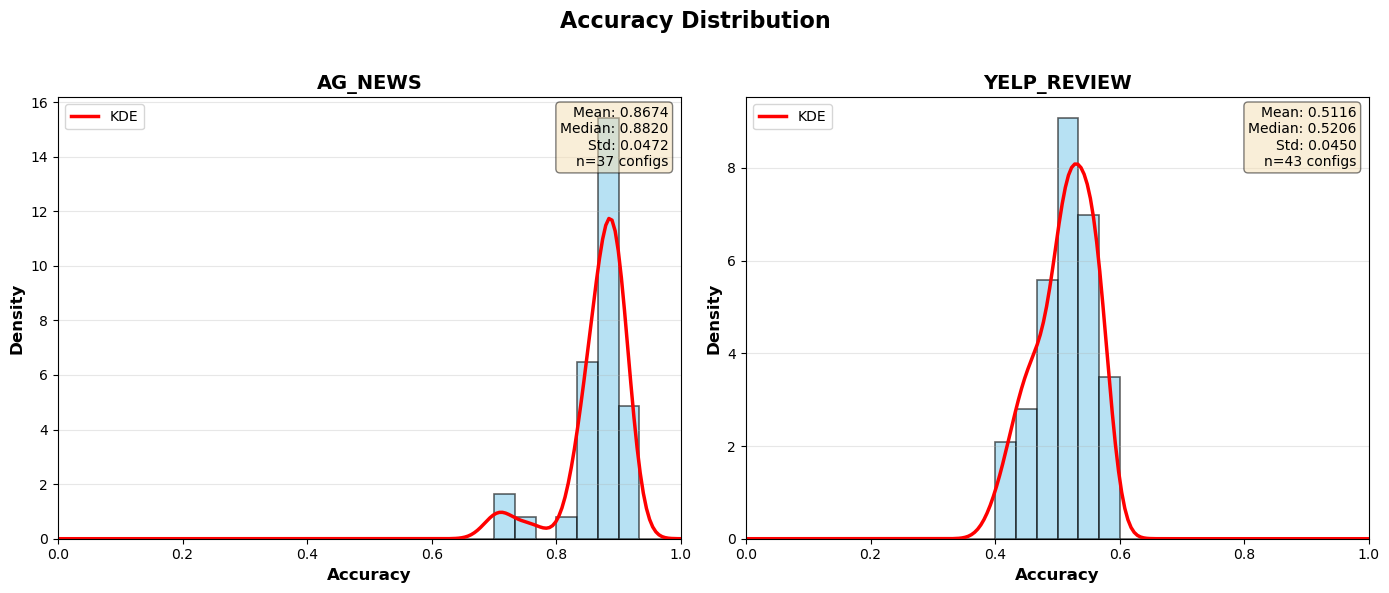


✓ Saved: accuracy_distribution_last_values.png


In [27]:
def plot_accuracy_histogram():
    """Plot accuracy distributions using histograms with KDE - LAST VALUES ONLY."""
    
    datasets = ['ag_news', 'yelp_review']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Accuracy Distribution',
                fontsize=16, fontweight='bold', y=0.98)
    
    for idx, dataset in enumerate(datasets):
        data_dir = f'/home/aditya/hack_model/results_datainfo_{dataset}'
        experiments = load_accuracy_data(dataset, data_dir)
        
        # Collect ONLY last accuracy value from each experiment
        all_acc_values = []
        for exp in experiments:
            acc_arr = exp['accuracy_arr']
            if isinstance(acc_arr, list):
                acc_arr = np.array(acc_arr)
            
            # Take the last value (could be last element or last row's last element)
            last_val = acc_arr.flatten()[-1]  # ← Get last value
            all_acc_values.append(last_val)
        
        ax = axes[idx]
        
        # Histogram
        ax.hist(all_acc_values, bins=30, density=True, 
                alpha=0.6, color='skyblue', edgecolor='black', linewidth=1.2,
                range=(0, 1))
        
        # KDE
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(all_acc_values)
        x_range = np.linspace(0, 1, 200)
        ax.plot(x_range, kde(x_range), 'r-', linewidth=2.5, label='KDE')
        
        ax.set_xlim(0, 1)
        ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
        ax.set_ylabel('Density', fontsize=12, fontweight='bold')
        ax.set_title(f'{dataset.upper()}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(fontsize=10)
        
        # Stats
        mean_acc = np.mean(all_acc_values)
        median_acc = np.median(all_acc_values)
        std_acc = np.std(all_acc_values)
        
        stats_text = (f'Mean: {mean_acc:.4f}\nMedian: {median_acc:.4f}\n'
                     f'Std: {std_acc:.4f}\nn={len(all_acc_values)} configs')
        ax.text(0.98, 0.98, stats_text,
               transform=ax.transAxes,
               fontsize=10,
               verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('accuracy_distribution_last_values.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Saved: accuracy_distribution_last_values.png")

plot_accuracy_histogram()

In [29]:
def distance_of_proportions(X, no_of_classes, ddof=0):
    """
    X: array shape (N,3) with values in [0,1]
    returns:
      P: normalized proportions, shape (N,3)
    """
    X = np.asarray(X, dtype=float)
    P = X / X.sum(axis=1, keepdims=True)
    l1 = np.sum(np.abs(P - float(1/no_of_classes)), axis=1)
    return l1

In [30]:
def load_all_proportions(dataset, base_dir):
    """
    Load all proportion configurations for a dataset.
    
    Args:
        dataset: 'ag_news' or 'yelp_review'
        base_dir: Directory containing experiment folders
    
    Returns:
        List of proportion arrays
    """
    from pathlib import Path
    
    base_path = Path(base_dir)
    
    # Find all directories for this dataset
    all_dirs = [d for d in base_path.iterdir() 
                if d.is_dir() and d.name.startswith(dataset)]
    
    proportions_list = []
    
    for exp_dir in all_dirs:
        props = parse_proportion_from_filename(exp_dir.name)
        if props is not None:
            proportions_list.append(props)
    
    print(f"✓ Found {len(proportions_list)} configurations for {dataset}")
    return proportions_list

# Usage
if __name__ == "__main__":
    
    datasets = ['ag_news', 'yelp_review']
    
    for dataset in datasets:
        base_dir = f'/home/aditya/hack_model/results_datainfo_{dataset}'
        proportions = load_all_proportions(dataset, base_dir)
        
        print(f"\n{dataset.upper()} Proportions:")
        for p in proportions[:5]:  # Show first 5
            print(f"  {p}")

✓ Found 37 configurations for ag_news

AG_NEWS Proportions:
  [0.43, 0.44, 0.01, 0.12]
  [0.1, 0.11, 0.34, 0.45]
  [0.02, 0.34, 0.37, 0.27]
  [0.03, 0.25, 0.34, 0.38]
  [0.11, 0.44, 0.43, 0.02]
✓ Found 43 configurations for yelp_review

YELP_REVIEW Proportions:
  [0.22, 0.2, 0.21, 0.15, 0.22]
  [0.45, 0.06, 0.16, 0.26, 0.07]
  [0.12, 0.17, 0.54, 0.1, 0.07]
  [0.28, 0.05, 0.31, 0.06, 0.3]
  [0.1, 0.05, 0.05, 0.67, 0.13]


✓ Found 37 configurations for ag_news
✓ Found 43 configurations for yelp_review


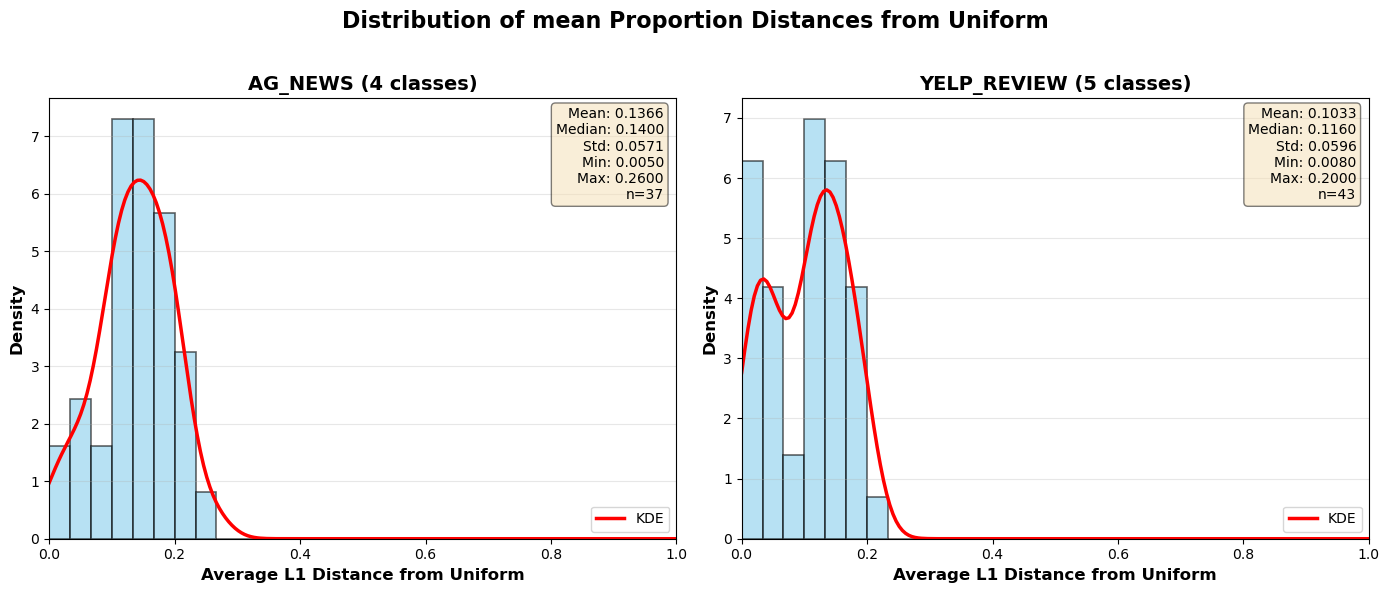


✓ Saved: proportion_distance_distribution.png


In [35]:
def plot_proportion_distance_distribution():
    """Plot distribution of proportion distances from uniform."""
    
    datasets = ['ag_news', 'yelp_review']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Distribution of mean Proportion Distances from Uniform',
                fontsize=16, fontweight='bold', y=0.98)
    
    for idx, dataset in enumerate(datasets):
        
        if dataset == 'ag_news':
            base_dir = '/home/aditya/hack_model/results_datainfo_ag_news'
            n_classes = 4
        else:  # yelp_review
            base_dir = '/home/aditya/hack_model/results_datainfo_yelp_review'
            n_classes = 5
        
        # Load all proportions using existing function
        proportions_list = load_all_proportions(dataset, base_dir)
        
        # Compute distances
        distances = [compute_proportion_distance(props, n_classes) 
                    for props in proportions_list]
        
        ax = axes[idx]
        
        # Histogram with fixed range
        ax.hist(distances, bins=30, density=True, 
                alpha=0.6, color='skyblue', edgecolor='black', 
                linewidth=1.2, range=(0, 1))  # ✅ Fixed range
        
        # KDE overlay (computed on full data, plotted over [0,1])
        if len(distances) > 1:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(distances)
            x_range = np.linspace(0, 1, 200)  # ✅ Fixed x-range
            ax.plot(x_range, kde(x_range), 'r-', 
                   linewidth=2.5, label='KDE')
        
        # Statistics
        mean_dist = np.mean(distances)
        median_dist = np.median(distances)
        std_dist = np.std(distances)
        min_dist = np.min(distances)
        max_dist = np.max(distances)
        
        # Formatting
        ax.set_xlim(0, 1)  # ✅ Force x-axis limits
        ax.set_xlabel('Average L1 Distance from Uniform', 
                     fontsize=12, fontweight='bold')
        ax.set_ylabel('Density', fontsize=12, fontweight='bold')
        ax.set_title(f'{dataset.upper()} ({n_classes} classes)', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(fontsize=10)
        
        # Add statistics box
        stats_text = (f'Mean: {mean_dist:.4f}\n'
                     f'Median: {median_dist:.4f}\n'
                     f'Std: {std_dist:.4f}\n'
                     f'Min: {min_dist:.4f}\n'
                     f'Max: {max_dist:.4f}\n'
                     f'n={len(distances)}')
        
        ax.text(0.98, 0.98, stats_text,
               transform=ax.transAxes,
               fontsize=10,
               verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('proportion_distance_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Saved: proportion_distance_distribution.png")


def compute_proportion_distance(proportions, n_classes):
    """Compute L1 distance from uniform distribution."""
    proportions = np.array(proportions)
    uniform = np.full(n_classes, 1.0 / n_classes)
    return np.mean(np.abs(proportions - uniform))


# Run it
plot_proportion_distance_distribution()